## 1. Imports and setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from implied_volatility_diffusion import (
    SurfaceNormalizer,
    UnifiedGrid,
    merge_config_files,
)
from implied_volatility_diffusion.data.historical_data_smoothing_interpolation import (
    load_cleaned_data,
)
from implied_volatility_diffusion.data.historical_sabr_interpolation import (
    build_historical_sabr_surface,
)
from implied_volatility_diffusion.synthetic.heston import (
    implied_vol_surfaces_heston_sequential_lhs,
    load_heston_iv_surface_config,
)
from implied_volatility_diffusion.synthetic.sabr import (
    implied_vol_surfaces_sabr_sequential_lhs,
)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 110, "axes.grid": False})

In [3]:
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CFG_DIR = REPO_ROOT / "config"
DATA_DIR = REPO_ROOT / "data"
PROCESSED_PARQUET = DATA_DIR / "processed" / "processed.parquet"

OUT_ROOT = DATA_DIR / "processed" / "forecasting_dataset"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

In [4]:
GRID = UnifiedGrid.load(CFG_DIR / "unified_iv_grid.yaml")
K_AXIS = GRID.log_moneyness
TAU_AXIS = GRID.tau
KK, TT = GRID.meshgrid()
print("unified grid:", GRID.shape, "  k in", (float(K_AXIS[0]), float(K_AXIS[-1])), "  tau in", (float(TAU_AXIS[0]), float(TAU_AXIS[-1])))

SAMPLE_DATE = pd.Timestamp("2021-06-17")
HIST_WINDOW_DAYS = 10
SEED = 42

# Risk-neutral assumptions used for the historic SABR calibration
HIST_R = 0.03
HIST_Q = 0.0
HIST_BETA = 0.5

print("sample date  :", SAMPLE_DATE.date(), " (±", HIST_WINDOW_DAYS, "business days on each side for the historic sequential block)")
print(f"historic SABR: r = {HIST_R}, q = {HIST_Q}, beta = {HIST_BETA}")

unified grid: (41, 40)   k in (-0.5, 0.5000000000000003)   tau in (0.05, 2.000000000000001)
sample date  : 2021-06-17  (± 10 business days on each side for the historic sequential block)
historic SABR: r = 0.03, q = 0.0, beta = 0.5


## Historic data pipeline

In [ ]:
t0 = time.perf_counter()
df = load_cleaned_data(PROCESSED_PARQUET)
print(f"loaded {len(df):,} rows in {time.perf_counter() - t0:.1f}s")
print("quote date span:", df['quote_date'].min().date(), "->", df['quote_date'].max().date())

loaded 15,409,923 rows in 7.1s
quote date span: 2019-01-02 → 2023-12-29


In [6]:
unique_dates = np.sort(df["quote_date"].dropna().unique())
unique_dates = pd.DatetimeIndex(unique_dates)
center_idx = int(np.searchsorted(unique_dates, SAMPLE_DATE))
if center_idx >= len(unique_dates) or unique_dates[center_idx] != SAMPLE_DATE:
    raise ValueError(f"Sample date {SAMPLE_DATE.date()} not present in cleaned dataset.")

lo = max(center_idx - HIST_WINDOW_DAYS, 0)
hi = min(center_idx + HIST_WINDOW_DAYS + 1, len(unique_dates))
window_dates = unique_dates[lo:hi]
SYNTH_WINDOW_STEPS = int(len(window_dates))
print(f"historic window: {len(window_dates)} days from {window_dates[0].date()} to {window_dates[-1].date()}")
print(f"synthetic target: {SYNTH_WINDOW_STEPS} sequential steps to match historic days")

historic window: 21 days from 2021-06-03 to 2021-07-01
synthetic target: 21 sequential steps to match historic days


In [7]:
hist_results: dict[pd.Timestamp, object] = {}
hist_stack = np.full((len(window_dates), *GRID.shape), np.nan, dtype=float)
hist_quote_counts = np.zeros(len(window_dates), dtype=int)
hist_n_expiries = np.zeros(len(window_dates), dtype=int)
hist_spot = np.zeros(len(window_dates), dtype=float)

t0 = time.perf_counter()
for i, d in enumerate(window_dates):
    day_df = df[df["quote_date"] == d]
    res = build_historical_sabr_surface(
        day_df,
        k_grid=K_AXIS,
        tau_grid=TAU_AXIS,
        r=HIST_R,
        q=HIST_Q,
        beta=HIST_BETA,
    )
    surf = res.surface
    hist_results[d] = res
    hist_stack[i] = surf
    hist_quote_counts[i] = len(res.day_sub)
    hist_n_expiries[i] = int(res.expiry_taus.size)
    hist_spot[i] = float(res.spot)


hist_sample = hist_results[SAMPLE_DATE]

## Synthetic Heston-COS surface - Unified grid

In [8]:
HESTON_PATHS = 1
HESTON_STEPS = SYNTH_WINDOW_STEPS

heston_cfg_raw = load_heston_iv_surface_config(CFG_DIR)
heston_cfg = GRID.with_config(heston_cfg_raw)

t0 = time.perf_counter()
heston_params, heston_m, heston_tau, heston_iv_native = implied_vol_surfaces_heston_sequential_lhs(
    heston_cfg,
    n_samples=HESTON_PATHS,
    n_batches=1,
    n_steps=HESTON_STEPS,
    seed=SEED,
)

In [9]:
heston_stack = heston_iv_native.copy()
heston_sample = heston_stack[0, 0]
heston_raw_sample = heston_iv_native[0, 0]

## Synthetic SABR surface - Unified grid

In [10]:
SABR_PATHS = 1
SABR_STEPS = SYNTH_WINDOW_STEPS

sabr_cfg_raw = merge_config_files(CFG_DIR / "sabr_iv_surface.yaml")
sabr_cfg = GRID.with_config(sabr_cfg_raw)

t0 = time.perf_counter()
sabr_params, sabr_m, sabr_tau, sabr_iv_native = implied_vol_surfaces_sabr_sequential_lhs(
    sabr_cfg,
    n_samples=SABR_PATHS,
    n_batches=1,
    n_steps=SABR_STEPS,
    seed=SEED,
)
print(f"SABR sequential LHS: {sabr_iv_native.shape} in {time.perf_counter() - t0:.1f}s")

sabr_stack = sabr_iv_native.copy()
print("SABR stack finite fraction:", float(np.isfinite(sabr_stack).mean()))

sabr_sample = sabr_stack[0, 0]
sabr_raw_sample = sabr_iv_native[0, 0]

SABR sequential LHS: (1, 21, 41, 40) in 0.3s
SABR stack finite fraction: 1.0


## Fit per-pixel normalizer on data

In [11]:
heston_flat = heston_stack.reshape(-1, *GRID.shape)
sabr_flat = sabr_stack.reshape(-1, *GRID.shape)

n_hist = int(hist_stack.shape[0])
n_heston = int(heston_flat.shape[0])
n_sabr = int(sabr_flat.shape[0])
n_total = n_hist + n_heston + n_sabr

# Pool every source into a single (N_total, I, J) training stack.
combined_stack = np.concatenate([hist_stack, heston_flat, sabr_flat], axis=0)
source_ids = np.concatenate([
    np.full(n_hist, 0, dtype=np.int8),
    np.full(n_heston, 1, dtype=np.int8),
    np.full(n_sabr, 2, dtype=np.int8),
])
source_labels = {0: "historic", 1: "heston", 2: "sabr"}

print("GLOBAL combined training stack")
print(f"  historic surfaces        : {n_hist:>6d}")
print(f"  heston   surfaces (P × S): {n_heston:>6d}  ({HESTON_PATHS} paths × {HESTON_STEPS} steps)")
print(f"  sabr     surfaces (P × S): {n_sabr:>6d}  ({SABR_PATHS} paths × {SABR_STEPS} steps)")
print(f"  TOTAL  N                 : {n_total:>6d}")
print(f"  stack shape              : {combined_stack.shape}")
print(f"  finite fraction          : {float(np.isfinite(combined_stack).mean()):.6f}")

normalizer = SurfaceNormalizer(grid_shape=GRID.shape).fit(combined_stack)

# Sanity-check that EVERY pixel's fit count == N_total (i.e. no source was silently dropped)
assert np.all(normalizer.count == n_total), (
    f"pixel fit-counts should all equal N_total={n_total}, got range "
    f"({int(normalizer.count.min())}, {int(normalizer.count.max())}); "
    "some surfaces had NaN pixels and were excluded from the global fit"
)

print("\nGLOBAL normalizer fitted on all sources:")
print(f"  μ  (per-pixel mean log σ) range : [{float(normalizer.mean.min()):+.4f}, {float(normalizer.mean.max()):+.4f}]")
print(f"  σ* (per-pixel std  log σ) range : [{float(normalizer.std.min()):.4f}, {float(normalizer.std.max()):.4f}]")
print(f"  pixel fit-count (all == N_total): {int(normalizer.count.min())} — {int(normalizer.count.max())}")

GLOBAL combined training stack
  historic surfaces        :     21
  heston   surfaces (P × S):     21  (1 paths × 21 steps)
  sabr     surfaces (P × S):     21  (1 paths × 21 steps)
  TOTAL  N                 :     63
  stack shape              : (63, 41, 40)
  finite fraction          : 1.000000

GLOBAL normalizer fitted on all sources:
  μ  (per-pixel mean log σ) range : [-2.8675, -1.8531]
  σ* (per-pixel std  log σ) range : [1.1976, 1.6339]
  pixel fit-count (all == N_total): 63 — 63


In [12]:
hist_z = normalizer.transform(hist_stack)
heston_z = normalizer.transform(heston_flat).reshape(heston_stack.shape)
sabr_z = normalizer.transform(sabr_flat).reshape(sabr_stack.shape)

hist_denorm = normalizer.inverse_transform(hist_z)
heston_denorm = normalizer.inverse_transform(heston_z.reshape(-1, *GRID.shape)).reshape(heston_stack.shape)
sabr_denorm = normalizer.inverse_transform(sabr_z.reshape(-1, *GRID.shape)).reshape(sabr_stack.shape)

hist_idx_sample = int(np.where(window_dates == SAMPLE_DATE)[0][0])
hist_sample_z = hist_z[hist_idx_sample]
hist_sample_denorm = hist_denorm[hist_idx_sample]
heston_sample_z = heston_z[0, 0]
heston_sample_denorm = heston_denorm[0, 0]
sabr_sample_z = sabr_z[0, 0]
sabr_sample_denorm = sabr_denorm[0, 0]

# Roundtrip fidelity (must be machine epsilon for every source)
for name, a, b in [
    ("historic", hist_stack, hist_denorm),
    ("heston", heston_stack, heston_denorm),
    ("sabr", sabr_stack, sabr_denorm),
]:
    diff = np.abs(a - b)
    print(f"roundtrip |σ − denorm(norm(σ))|  [{name:8s}]  max = {np.nanmax(diff):.2e}   mean = {np.nanmean(diff):.2e}")

combined_z = np.concatenate([
    hist_z.reshape(-1, *GRID.shape),
    heston_z.reshape(-1, *GRID.shape),
    sabr_z.reshape(-1, *GRID.shape),
], axis=0)

print("\nz-score diagnostics on the GLOBAL pool (expect mean ≈ 0, std ≈ 1):")
print(f"  combined   N={combined_z.shape[0]:>5d}   mean = {combined_z.mean():+.4f}   std = {combined_z.std():.4f}")
print(f"  historic   N={hist_z.shape[0]:>5d}   mean = {hist_z.mean():+.4f}   std = {hist_z.std():.4f}")
print(f"  heston     N={heston_z.reshape(-1, *GRID.shape).shape[0]:>5d}   mean = {heston_z.mean():+.4f}   std = {heston_z.std():.4f}")
print(f"  sabr       N={sabr_z.reshape(-1, *GRID.shape).shape[0]:>5d}   mean = {sabr_z.mean():+.4f}   std = {sabr_z.std():.4f}")

roundtrip |σ − denorm(norm(σ))|  [historic]  max = 2.22e-16   mean = 1.24e-17
roundtrip |σ − denorm(norm(σ))|  [heston  ]  max = 1.11e-16   mean = 9.95e-18
roundtrip |σ − denorm(norm(σ))|  [sabr    ]  max = 6.94e-18   mean = 2.67e-18

z-score diagnostics on the GLOBAL pool (expect mean ≈ 0, std ≈ 1):
  combined   N=   63   mean = +0.0000   std = 0.9920
  historic   N=   21   mean = +0.6100   std = 0.1113
  heston     N=   21   mean = +0.7837   std = 0.1058
  sabr       N=   21   mean = -1.3937   std = 0.0096


## Save with sequential layout

In [ ]:
hist_dir = OUT_ROOT / "historical"
hist_dir.mkdir(parents=True, exist_ok=True)
np.save(hist_dir / "surfaces.npy", hist_stack)
np.save(hist_dir / "surfaces_normalized.npy", hist_z)
np.save(hist_dir / "dates.npy", np.asarray(window_dates.values, dtype="datetime64[D]"))
np.save(hist_dir / "quote_counts.npy", hist_quote_counts)
np.save(hist_dir / "n_expiries_calibrated.npy", hist_n_expiries)
np.save(hist_dir / "spot.npy", hist_spot)

hist_meta = {
    "source": "historical_spx",
    "dataset": str(PROCESSED_PARQUET.relative_to(REPO_ROOT)),
    "pipeline": [
        "filter_day_for_surface (k, tau, iv, vega bounds)",
        "group quotes by expiry",
        "per-expiry Hagan-SABR calibration of (alpha, rho, nu) with fixed beta",
        "evaluate SABR lognormal closed-form on the unified (k, tau) grid (interpolates across strikes, extrapolates across maturities via nearest-expiry slice)",
        "per-pixel log-sigma z-score normalization (shared normalizer)",
    ],
    "sabr": {"beta": HIST_BETA, "r": HIST_R, "q": HIST_Q},
    "axis_order": ["day", "k", "tau"],
    "n_days": int(len(window_dates)),
    "sample_date": str(SAMPLE_DATE.date()),
    "sample_date_index": int(hist_idx_sample),
    "quote_date_range": [str(window_dates[0].date()), str(window_dates[-1].date())],
}
(hist_dir / "metadata.json").write_text(json.dumps(hist_meta, indent=2), encoding="utf-8")

historical -> /Users/sbonelomdluli/Desktop/implied-volatility-diffusion/data/processed/forecasting_dataset/historical


In [14]:
heston_dir = OUT_ROOT / "heston"
heston_dir.mkdir(parents=True, exist_ok=True)
heston_dt = float((heston_cfg.get("sequential_ivs") or {}).get("dt", 1.0 / 252.0))
heston_step_sec = np.arange(HESTON_STEPS, dtype=float) * heston_dt * 365.0
np.save(heston_dir / "surfaces.npy", heston_stack)
np.save(heston_dir / "surfaces_normalized.npy", heston_z)
np.save(heston_dir / "params.npy", heston_params)
np.save(heston_dir / "step_days.npy", heston_step_sec)

heston_meta = {
    "source": "synthetic_heston",
    "config": str((CFG_DIR / "heston_iv_surface.yaml").relative_to(REPO_ROOT)),
    "pipeline": [
        "Latin Hypercube sample of Heston (v0, rho, sigma_v, theta, kappa, r) with Feller clip",
        "Milstein integration of (S, v) under the risk-neutral measure",
        "Heston-COS European call prices on the unified (k, tau) grid at each step",
        "Jäckel implied-volatility inversion",
        "arbitrage guard (repair policy)",
        "per-pixel log-sigma z-score normalization (shared normalizer)",
    ],
    "param_order": ["v0", "rho", "sigma", "theta", "kappa", "r"],
    "axis_order": ["path", "step", "k", "tau"],
    "n_paths": int(HESTON_PATHS),
    "n_steps": int(HESTON_STEPS),
    "dt_years": heston_dt,
    "seed": int(SEED),
}
(heston_dir / "metadata.json").write_text(json.dumps(heston_meta, indent=2), encoding="utf-8")

739

In [15]:
sabr_dir = OUT_ROOT / "sabr"
sabr_dir.mkdir(parents=True, exist_ok=True)
sabr_dt = float((sabr_cfg.get("sequential_ivs") or {}).get("dt", 1.0 / 252.0))
sabr_step_sec = np.arange(SABR_STEPS, dtype=float) * sabr_dt * 365.0
np.save(sabr_dir / "surfaces.npy", sabr_stack)
np.save(sabr_dir / "surfaces_normalized.npy", sabr_z)
np.save(sabr_dir / "params.npy", sabr_params)
np.save(sabr_dir / "step_days.npy", sabr_step_sec)

sabr_meta = {
    "source": "synthetic_sabr",
    "config": str((CFG_DIR / "sabr_iv_surface.yaml").relative_to(REPO_ROOT)),
    "pipeline": [
        "Latin Hypercube sample of SABR (alpha, rho, nu) with fixed beta",
        "SABR SDE Euler step for (S, alpha) under the risk-neutral measure",
        "Hagan lognormal implied vol closed-form on the unified (k, tau) grid at each step",
        "arbitrage guard (repair policy)",
        "per-pixel log-sigma z-score normalization (shared normalizer)",
    ],
    "param_order": ["alpha", "rho", "nu"],
    "beta": float((sabr_cfg.get("sabr") or {}).get("beta", 0.5)),
    "axis_order": ["path", "step", "k", "tau"],
    "n_paths": int(SABR_PATHS),
    "n_steps": int(SABR_STEPS),
    "dt_years": sabr_dt,
    "seed": int(SEED),
}
(sabr_dir / "metadata.json").write_text(json.dumps(sabr_meta, indent=2), encoding="utf-8")

657

In [16]:
normalizer_path = OUT_ROOT / "normalizer.npz"
normalizer.save(normalizer_path)

manifest = {
    "sample_date": str(SAMPLE_DATE.date()),
    "grid": {
        "shape": list(GRID.shape),
        "config": str((CFG_DIR / "unified_iv_grid.yaml").relative_to(REPO_ROOT)),
    },
    "normalizer": {
        "path": str(normalizer_path.relative_to(REPO_ROOT)),
        "fit_sample_counts": {
            "historic": int(n_hist),
            "heston": int(n_heston),
            "sabr": int(n_sabr),
            "total": int(n_total),
        },
    },
    "sources": {
        "historical": str(hist_dir.relative_to(REPO_ROOT)),
        "heston": str(heston_dir.relative_to(REPO_ROOT)),
        "sabr": str(sabr_dir.relative_to(REPO_ROOT)),
    },
    "combined_training_stack_shape": list(combined_stack.shape),
}
(OUT_ROOT / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

599

## Plot the sample for 2021-06-17

In [17]:
ELEV, AZIM = 25.0, -55.0
CMAP_IV = "turbo"
CMAP_Z = "coolwarm"

@dataclass
class SampleBundle:
    name: str                        # "historic" / "heston" / "sabr"
    title: str                       
    raw_mode: str                    # "scatter" or "surface"
    raw_k: np.ndarray | None
    raw_tau: np.ndarray | None
    raw_iv: np.ndarray               # (N,) for scatter, (I, J) for surface
    smoothed: np.ndarray             # (I, J) on unified grid
    normalized: np.ndarray           # (I, J) z-score
    denormalized: np.ndarray         # (I, J) sigma from inverse_transform(z)

hist_day_sub = hist_sample.day_sub
hist_sample_surface = hist_stack[hist_idx_sample]
bundles = [
    SampleBundle(
        name="historic",
        title=(
            f"Historic SPX — {SAMPLE_DATE.date()} "
            f"(n quotes = {len(hist_day_sub):,}, n SABR expiries = {hist_sample.expiry_taus.size})"
        ),
        raw_mode="scatter",
        raw_k=hist_day_sub["k"].to_numpy(dtype=float),
        raw_tau=hist_day_sub["tau"].to_numpy(dtype=float),
        raw_iv=hist_day_sub["iv"].to_numpy(dtype=float),
        smoothed=hist_sample_surface,
        normalized=hist_sample_z,
        denormalized=hist_sample_denorm,
    ),
    SampleBundle(
        name="heston",
        title=f"Synthetic Heston — path 0, step 0 (sample-date slot)",
        raw_mode="surface",
        raw_k=K_AXIS,
        raw_tau=TAU_AXIS,
        raw_iv=heston_raw_sample,
        smoothed=heston_sample,
        normalized=heston_sample_z,
        denormalized=heston_sample_denorm,
    ),
    SampleBundle(
        name="sabr",
        title=f"Synthetic SABR — path 0, step 0 (sample-date slot)",
        raw_mode="surface",
        raw_k=K_AXIS,
        raw_tau=TAU_AXIS,
        raw_iv=sabr_raw_sample,
        smoothed=sabr_sample,
        normalized=sabr_sample_z,
        denormalized=sabr_sample_denorm,
    ),
]

def _iv_scale(b: SampleBundle) -> tuple[float, float]:
    finite = b.smoothed[np.isfinite(b.smoothed)]
    lo, hi = float(np.min(finite)), float(np.max(finite))
    span = max(hi - lo, 1e-6)
    return max(0.0, lo - 0.10 * span), hi + 0.15 * span

def _z_scale(b: SampleBundle) -> tuple[float, float]:
    finite = b.normalized[np.isfinite(b.normalized)]
    if finite.size == 0:
        return -1.0, 1.0
    v = float(np.max(np.abs(finite)))
    return -v, v

def _label_3d(ax):
    ax.set_xlabel("k = log(K/S)")
    ax.set_ylabel(r"$\tau$ (yrs)")
    ax.set_xlim(float(K_AXIS[0]), float(K_AXIS[-1]))
    ax.set_ylim(float(TAU_AXIS[0]), float(TAU_AXIS[-1]))
    ax.view_init(elev=ELEV, azim=AZIM)

def _label_heat(ax):
    ax.set_xlabel(r"$\tau$ (yrs)")
    ax.set_ylabel("k = log(K/S)")
    ax.set_xlim(float(TAU_AXIS[0]), float(TAU_AXIS[-1]))
    ax.set_ylim(float(K_AXIS[0]), float(K_AXIS[-1]))

HEAT_EXTENT = (float(TAU_AXIS[0]), float(TAU_AXIS[-1]), float(K_AXIS[0]), float(K_AXIS[-1]))

In [18]:
print("sample bundles prepared:", [b.name for b in bundles])

sample bundles prepared: ['historic', 'heston', 'sabr']


###  Raw -> Smoothed -> Normalized

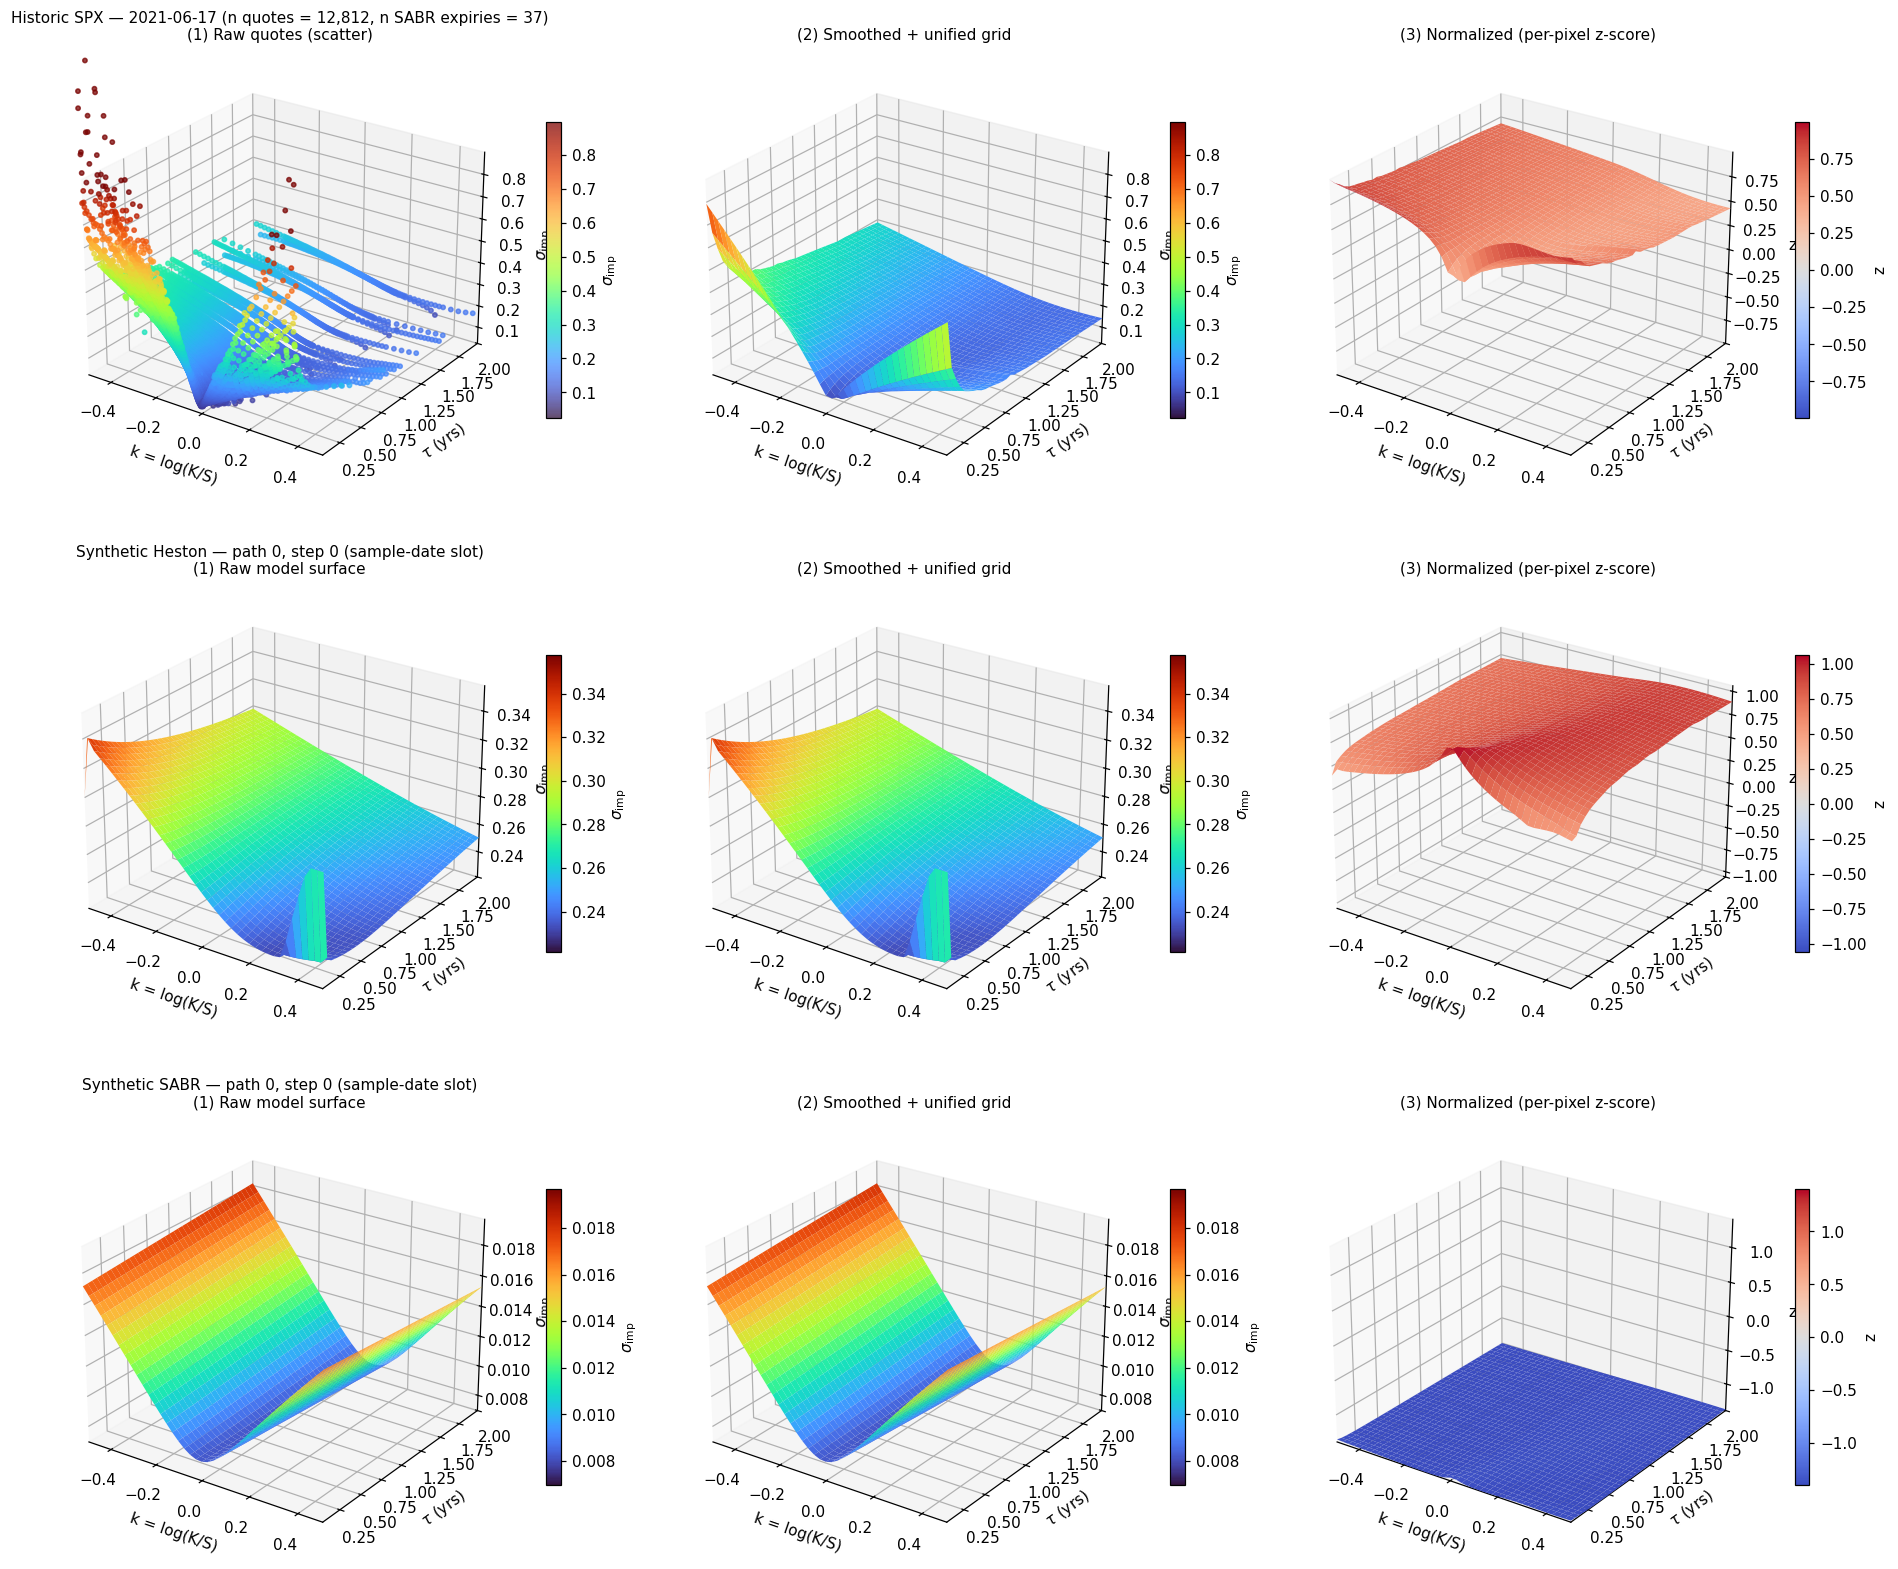

In [ ]:
fig = plt.figure(figsize=(17, 5.2 * len(bundles)))

for row, b in enumerate(bundles):
    iv_vmin, iv_vmax = _iv_scale(b)
    z_vmin, z_vmax = _z_scale(b)

    ax1 = fig.add_subplot(len(bundles), 3, row * 3 + 1, projection="3d")
    if b.raw_mode == "scatter":
        sc = ax1.scatter(
            b.raw_k, b.raw_tau, b.raw_iv,
            c=b.raw_iv, cmap=CMAP_IV, s=8, alpha=0.75, vmin=iv_vmin, vmax=iv_vmax,
        )
        fig.colorbar(sc, ax=ax1, shrink=0.55, pad=0.08, label=r"$\sigma_{\mathrm{imp}}$")
        ax1.set_title(f"{b.title}\n(1) Raw quotes (scatter)", fontsize=10)
    else:
        surf = ax1.plot_surface(KK, TT, b.raw_iv, cmap=CMAP_IV, edgecolor="none", vmin=iv_vmin, vmax=iv_vmax, antialiased=True)
        fig.colorbar(surf, ax=ax1, shrink=0.55, pad=0.08, label=r"$\sigma_{\mathrm{imp}}$")
        ax1.set_title(f"{b.title}\n(1) Raw model surface", fontsize=10)
    _label_3d(ax1)
    ax1.set_zlabel(r"$\sigma_{\mathrm{imp}}$")
    ax1.set_zlim(iv_vmin, iv_vmax)

    ax2 = fig.add_subplot(len(bundles), 3, row * 3 + 2, projection="3d")
    surf = ax2.plot_surface(KK, TT, b.smoothed, cmap=CMAP_IV, edgecolor="none", vmin=iv_vmin, vmax=iv_vmax, antialiased=True)
    fig.colorbar(surf, ax=ax2, shrink=0.55, pad=0.08, label=r"$\sigma_{\mathrm{imp}}$")
    ax2.set_title("(2) Smoothed + unified grid", fontsize=10)
    _label_3d(ax2)
    ax2.set_zlabel(r"$\sigma_{\mathrm{imp}}$")
    ax2.set_zlim(iv_vmin, iv_vmax)

    ax3 = fig.add_subplot(len(bundles), 3, row * 3 + 3, projection="3d")
    surf = ax3.plot_surface(KK, TT, b.normalized, cmap=CMAP_Z, edgecolor="none", vmin=z_vmin, vmax=z_vmax, antialiased=True)
    fig.colorbar(surf, ax=ax3, shrink=0.55, pad=0.08, label="z")
    ax3.set_title("(3) Normalized (per-pixel z-score)", fontsize=10)
    _label_3d(ax3)
    ax3.set_zlabel("z")
    ax3.set_zlim(z_vmin, z_vmax)

fig.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig("pipeline_3d.pdf", bbox_inches='tight')
plt.show()

### Heatmaps

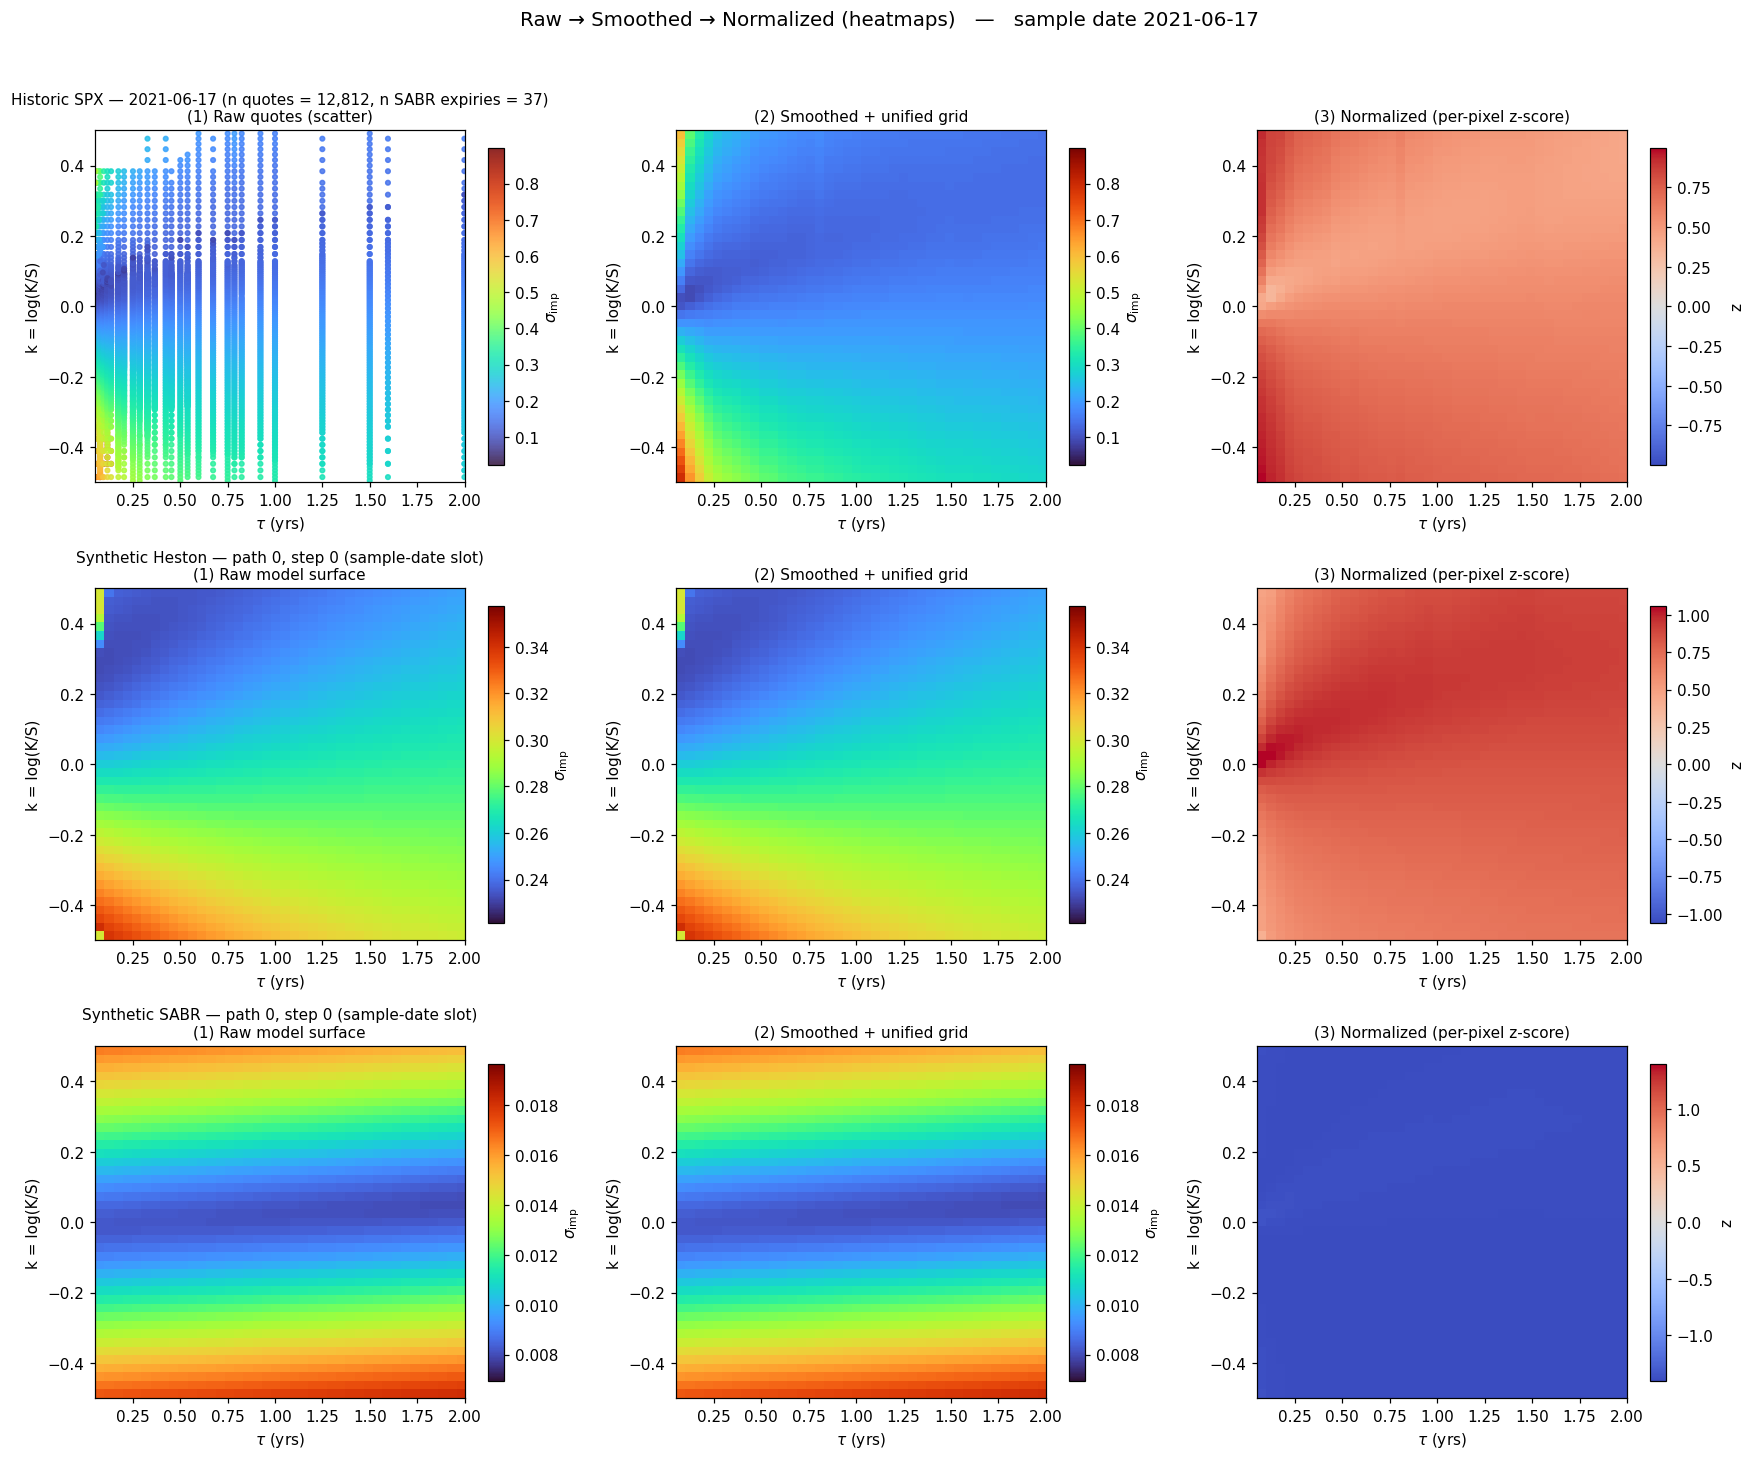

In [20]:
fig, axes = plt.subplots(len(bundles), 3, figsize=(16, 4.5 * len(bundles)))
if len(bundles) == 1:
    axes = np.atleast_2d(axes)
fig.suptitle(f"Raw → Smoothed → Normalized (heatmaps)   —   sample date {SAMPLE_DATE.date()}", fontsize=13)

for row, b in enumerate(bundles):
    iv_vmin, iv_vmax = _iv_scale(b)
    z_vmin, z_vmax = _z_scale(b)

    ax1 = axes[row, 0]
    if b.raw_mode == "scatter":
        sc = ax1.scatter(b.raw_tau, b.raw_k, c=b.raw_iv, cmap=CMAP_IV, s=9, alpha=0.85, vmin=iv_vmin, vmax=iv_vmax)
        fig.colorbar(sc, ax=ax1, shrink=0.9, label=r"$\sigma_{\mathrm{imp}}$")
        ax1.set_title(f"{b.title}\n(1) Raw quotes (scatter)", fontsize=10)
    else:
        im = ax1.imshow(b.raw_iv, origin="lower", aspect="auto", extent=HEAT_EXTENT, cmap=CMAP_IV, vmin=iv_vmin, vmax=iv_vmax)
        fig.colorbar(im, ax=ax1, shrink=0.9, label=r"$\sigma_{\mathrm{imp}}$")
        ax1.set_title(f"{b.title}\n(1) Raw model surface", fontsize=10)
    _label_heat(ax1)

    ax2 = axes[row, 1]
    im = ax2.imshow(b.smoothed, origin="lower", aspect="auto", extent=HEAT_EXTENT, cmap=CMAP_IV, vmin=iv_vmin, vmax=iv_vmax)
    fig.colorbar(im, ax=ax2, shrink=0.9, label=r"$\sigma_{\mathrm{imp}}$")
    ax2.set_title("(2) Smoothed + unified grid", fontsize=10)
    _label_heat(ax2)

    ax3 = axes[row, 2]
    im = ax3.imshow(b.normalized, origin="lower", aspect="auto", extent=HEAT_EXTENT, cmap=CMAP_Z, vmin=z_vmin, vmax=z_vmax)
    fig.colorbar(im, ax=ax3, shrink=0.9, label="z")
    ax3.set_title("(3) Normalized (per-pixel z-score)", fontsize=10)
    _label_heat(ax3)

fig.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig("pipeline_heatmap.pdf", bbox_inches='tight')
plt.show()

### Normalized to Denormalized

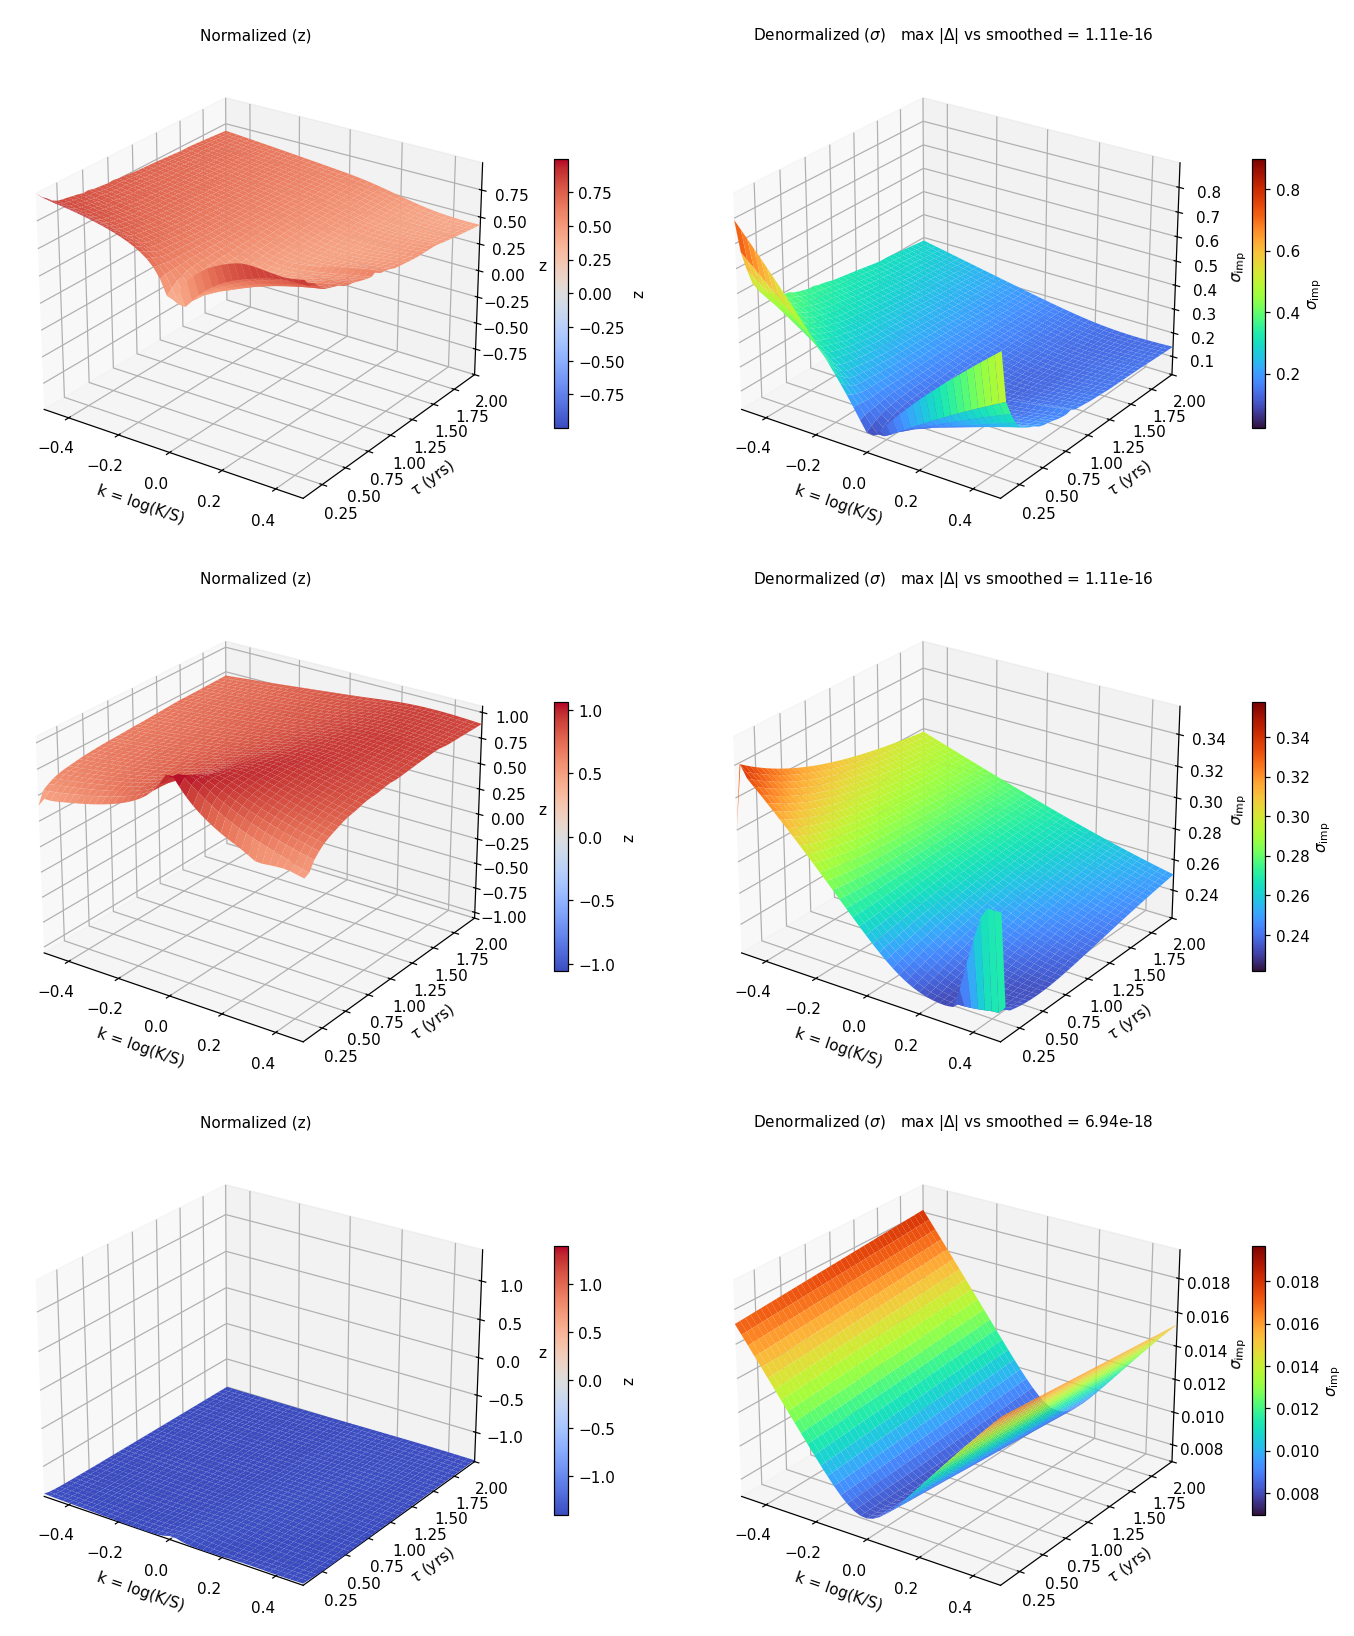

In [21]:
fig = plt.figure(figsize=(13, 5.2 * len(bundles)))

for row, b in enumerate(bundles):
    iv_vmin, iv_vmax = _iv_scale(b)
    z_vmin, z_vmax = _z_scale(b)

    ax_left = fig.add_subplot(len(bundles), 2, row * 2 + 1, projection="3d")
    surf = ax_left.plot_surface(KK, TT, b.normalized, cmap=CMAP_Z, edgecolor="none", vmin=z_vmin, vmax=z_vmax, antialiased=True)
    fig.colorbar(surf, ax=ax_left, shrink=0.55, pad=0.08, label="z")
    ax_left.set_title(f"\nNormalized (z)", fontsize=10)
    _label_3d(ax_left)
    ax_left.set_zlabel("z")
    ax_left.set_zlim(z_vmin, z_vmax)

    ax_right = fig.add_subplot(len(bundles), 2, row * 2 + 2, projection="3d")
    surf = ax_right.plot_surface(KK, TT, b.denormalized, cmap=CMAP_IV, edgecolor="none", vmin=iv_vmin, vmax=iv_vmax, antialiased=True)
    fig.colorbar(surf, ax=ax_right, shrink=0.55, pad=0.08, label=r"$\sigma_{\mathrm{imp}}$")
    diff = float(np.nanmax(np.abs(b.denormalized - b.smoothed)))
    ax_right.set_title(f"Denormalized ($\\sigma$)   max |Δ| vs smoothed = {diff:.2e}", fontsize=10)
    _label_3d(ax_right)
    ax_right.set_zlabel(r"$\sigma_{\mathrm{imp}}$")
    ax_right.set_zlim(iv_vmin, iv_vmax)

fig.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig("pipeline_normalization_roundtrip_3d.pdf", bbox_inches='tight')
plt.show()

### Heatmaps

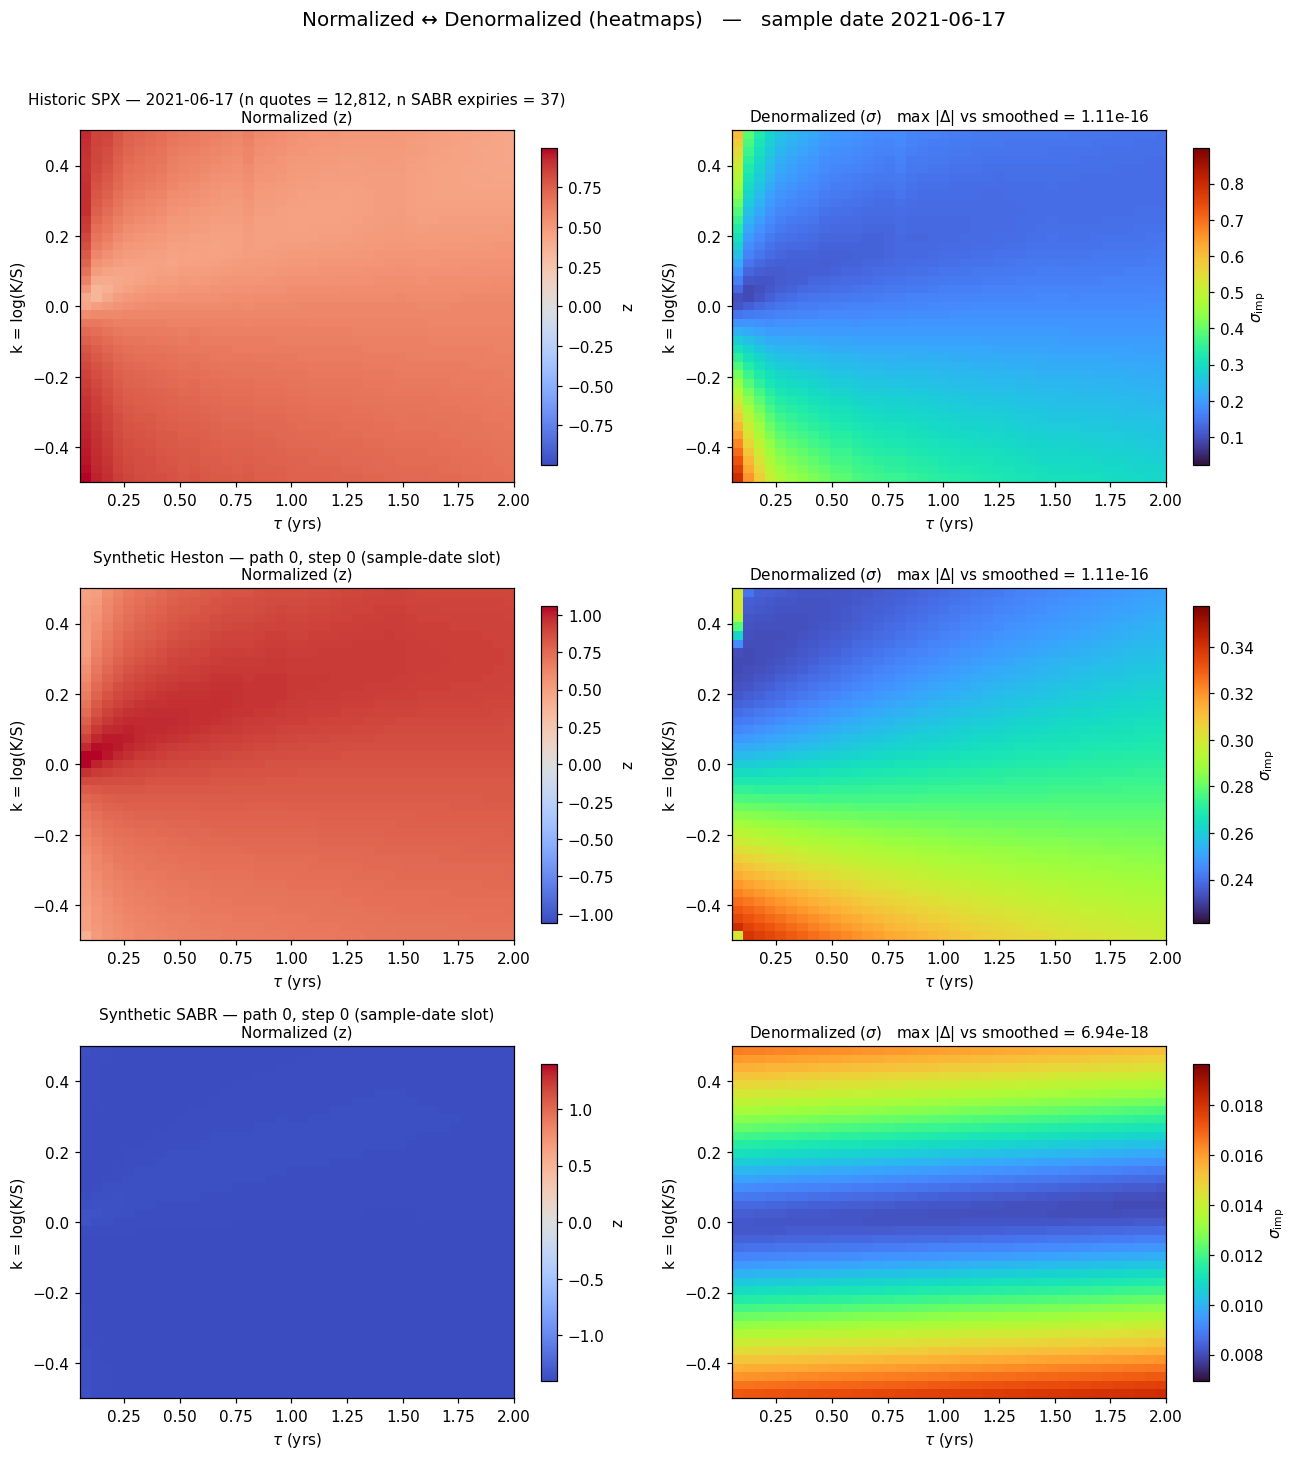

In [22]:
fig, axes = plt.subplots(len(bundles), 2, figsize=(12, 4.5 * len(bundles)))
if len(bundles) == 1:
    axes = np.atleast_2d(axes)
fig.suptitle(f"Normalized ↔ Denormalized (heatmaps)   —   sample date {SAMPLE_DATE.date()}", fontsize=13)

for row, b in enumerate(bundles):
    iv_vmin, iv_vmax = _iv_scale(b)
    z_vmin, z_vmax = _z_scale(b)

    ax_left = axes[row, 0]
    im = ax_left.imshow(b.normalized, origin="lower", aspect="auto", extent=HEAT_EXTENT, cmap=CMAP_Z, vmin=z_vmin, vmax=z_vmax)
    fig.colorbar(im, ax=ax_left, shrink=0.9, label="z")
    ax_left.set_title(f"{b.title}\nNormalized (z)", fontsize=10)
    _label_heat(ax_left)

    ax_right = axes[row, 1]
    im = ax_right.imshow(b.denormalized, origin="lower", aspect="auto", extent=HEAT_EXTENT, cmap=CMAP_IV, vmin=iv_vmin, vmax=iv_vmax)
    fig.colorbar(im, ax=ax_right, shrink=0.9, label=r"$\sigma_{\mathrm{imp}}$")
    diff = float(np.nanmax(np.abs(b.denormalized - b.smoothed)))
    ax_right.set_title(f"Denormalized ($\\sigma$)   max |Δ| vs smoothed = {diff:.2e}", fontsize=10)
    _label_heat(ax_right)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()